# Exercise 5

In [39]:
import pandas as pd
import numpy as np

from scipy import stats
from scipy.stats import chi2_contingency


## Part 1: ANOVA

A teacher wants to investigate whether different teaching methods affect students’ exam scores. The dataset contains 50 students, each assigned to one of three teaching methods (A, B, or C).

Question: "Is there a difference in mean exam scores among students taught using three different teaching methods?"

- Independent variable (factor): Teaching Method (A, B, C)
- Dependent variable: Exam Score (numeric)

In [40]:
url = "https://github.com/robitussin/CCDATSCL_EXERCISES/blob/f56f00991116fcb717a8827d324aa6f599dea366/exam_scores.csv?raw=true"

df_exam_scores = pd.read_csv(url)
df_exam_scores


,StudentID,Method,Score
0,1,A,79
1,2,A,77
2,3,A,82
3,4,A,75
4,5,A,80
5,6,A,78
6,7,A,83
7,8,A,76
8,9,A,81
9,10,A,74


Calculate the number of students in each teaching method.

In [41]:
# put your answer here
num_of_students = df_exam_scores['Method'].value_counts()
num_of_students

,count
Method,
A,17
B,17
C,16


Compute the mean and standard deviation of exam scores for each group.

In [42]:
# put your answer here
mean_exam_scores = df_exam_scores.groupby('Method')['Score'].mean()
mean_exam_scores

,Score
Method,
A,78.588235
B,86.294118
C,71.937500


In [43]:
std_exam_scores = df_exam_scores.groupby('Method')['Score'].std()
std_exam_scores

,Score
Method,
A,2.575336
B,2.365500
C,1.768945


Use a plot to show the exam scores by teaching method.

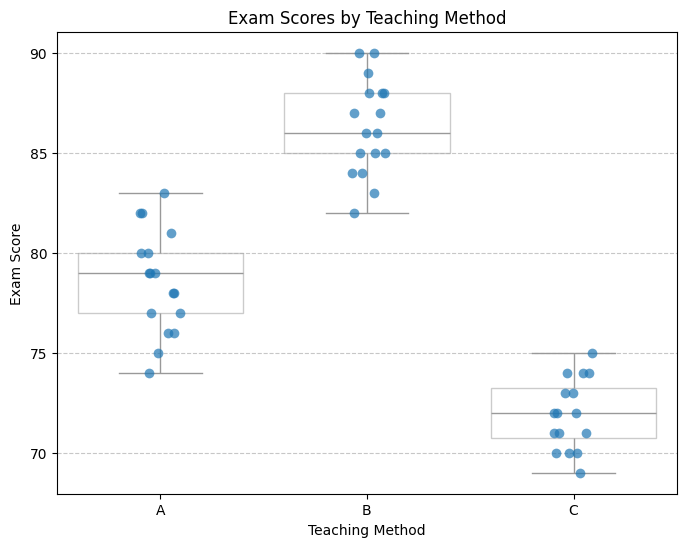

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.stripplot(x='Method', y='Score', data=df_exam_scores, jitter=True, alpha=0.7, size=7)
sns.boxplot(x='Method', y='Score', data=df_exam_scores, color='white', boxprops={'alpha': 0.5})

plt.title("Exam Scores by Teaching Method")
plt.xlabel("Teaching Method")
plt.ylabel("Exam Score")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.show()

Perform the ANOVA Test
- Use scipy.stats.f_oneway to conduct a one-way ANOVA.
- Report the F-statistic and p-value.
- Using a significance level of α = 0.05, state whether you reject or fail to reject H₀.

In [45]:
# put your answer here
f_statistic, p_value = stats.f_oneway(df_exam_scores['Method'] == 'A', df_exam_scores['Method'] == 'B', df_exam_scores['Method'] == 'C')

print("F-statistic:", f_statistic)
print("p-value:", p_value)

F-statistic: 0.02941176470588237
p-value: 0.9710222644330399


In [46]:
# Interpretation
alpha = 0.05
if p_value > alpha:
    print("Significant difference found (Reject H0)")
else:
    print("No significant difference found (Fail to reject H0)")

Significant difference found (Reject H0)


Interpret the results. What does it say about the relationship between teaching method and exam scores?

In [47]:
# put your answer here
print("Given that we rejected the null hypothesis (H₀) in the ANOVA test, therefore, there is a statistically significant evidence to conclude that the mean exam scores differ among the 3 teaching methods. Based on this analysis, the teaching methods appear to have a significant impact on students' exam scores.")

Given that we rejected the null hypothesis (H₀) in the ANOVA test, therefore, there is a statistically significant evidence to conclude that the mean exam scores differ among the 3 teaching methods. Based on this analysis, the teaching methods appear to have a significant impact on students' exam scores.


## Part 2: Chi-squared

A survey was conducted to see if there is a relationship between gender and littering behavior.

Question:
"Is gender associated with littering behavior?"

Each row represents one person.

In [48]:
url = "https://github.com/robitussin/CCDATSCL_EXERCISES/blob/f56f00991116fcb717a8827d324aa6f599dea366/litteringdata.csv?raw=true"

df_littering_data = pd.read_csv(url)
df_littering_data

,ID,Gender,Litter
0,1,Male,Yes
1,2,Male,Yes
2,3,Male,Yes
3,4,Male,Yes
4,5,Male,Yes
5,6,Male,Yes
6,7,Male,Yes
7,8,Male,Yes
8,9,Male,Yes
9,10,Male,Yes


Count the number of observations in each category for Gender and Litter separately.

In [49]:
# put your answer here
gender_counts = df_littering_data['Gender'].value_counts()
gender_counts

,count
Gender,
Male,20
Female,20


In [50]:
# put your answer here
litter_counts = df_littering_data['Litter'].value_counts()
litter_counts

,count
Litter,
No,22
Yes,18


Using `pd.crosstab()`, create a contingency table showing counts of littering behavior for each gender.
- Write down the row totals, column totals, and grand total from the table.

In [51]:
# put your answer here
contingency_table = pd.crosstab(df_littering_data['Gender'], df_littering_data['Litter'], margins=True)
contingency_table

Litter,No,Yes,All
Gender,,,
Female,14,6,20
Male,8,12,20
All,22,18,40


State the null hypothesis (H₀) and alternative hypothesis (H₁) for this chi-squared test.

In [52]:
# put your answer here
print("Null Hypothesis (H₀): There is no association between gender and littering behavior.")
print("Alternative Hypothesis (H₁): There is an association between gender and littering behavior.")

Null Hypothesis (H₀): There is no association between gender and littering behavior.
Alternative Hypothesis (H₁): There is an association between gender and littering behavior.


Use scipy.stats.chi2_contingency to calculate:
- Chi-squared statistic
- p-value
- Degrees of freedom

Using a significance level of `α = 0.05`, determine whether to reject or fail to reject H₀.


In [53]:
# put your answer here
chi2, p, dof, expected = chi2_contingency(contingency_table.iloc[:-1, :-1])

print("Chi-squared statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-squared statistic: 2.525252525252525
p-value: 0.11203684368556356
Degrees of freedom: 1


In [54]:
# Interpretation
alpha = 0.05
if p_value < alpha:
    print("Significant difference found (Reject H0)")
else:
    print("No significant difference found (Fail to reject H0)")

No significant difference found (Fail to reject H0)


Interpret your results. Is there evidence that gender and littering behavior are associated?

In [55]:
# put your answer here
print(f"Given that the p-value ({p:.3f}) is greater than the significance level (α = {alpha}), we fail to reject the null hypothesis (H₀). Therefore, there is no statistically significant evidence to suggest an association between gender and littering behavior in this dataset.")

Given that the p-value (0.112) is greater than the significance level (α = 0.05), we fail to reject the null hypothesis (H₀). Therefore, there is no statistically significant evidence to suggest an association between gender and littering behavior in this dataset.
